# Buổi 5 - Tích hợp OCR và đánh giá toàn hệ thống

Notebook này dùng để học lại toàn bộ luồng Buổi 5 và xem kết quả định lượng của pipeline nhận diện biển số Việt Nam.

Trọng tâm của Buổi 5 dựa trên quyết định từ Buổi 4:

- Pipeline chính: **DeepSolo localize + TrOCR OCR**.
- Baseline dự phòng: **YOLOv8 + TrOCR** hoặc **YOLOv8 + EasyOCR**.
- Metric bắt buộc: **CER**, **WER**, **plate-level accuracy**, và nếu có thì **latency**.
- Mục tiêu thực tế: chạy trên test set cố định có ít nhất 200 ảnh biển số thật.

Nếu chưa có prediction thật, notebook sẽ tự tạo một bộ dữ liệu demo nhỏ để kiểm tra công thức metric và cách đọc báo cáo.

## 1. Mục tiêu học trong notebook

Sau khi chạy notebook này, bạn cần nắm được:

- Vì sao Buổi 5 chọn DeepSolo + TrOCR làm tuyến chính sau Buổi 4.
- Một prediction file cần có những cột nào để đánh giá OCR.
- Cách tính CER, WER và plate-level accuracy.
- Cách đọc bảng kết quả, phân tích lỗi và chọn việc cải thiện trước Buổi 6.
- Cách thay dữ liệu demo bằng kết quả inference thật từ pipeline.

## 2. Hiểu tận gốc bài toán

Nhận diện biển số không phải là một bài toán duy nhất. Nó là một chuỗi các bài toán nhỏ nối nhau:

1. **Ảnh có biển số ở đâu?** Đây là bài toán localization/detection.
2. **Cắt vùng biển như thế nào để chữ rõ nhất?** Đây là bài toán crop, rectify và preprocess.
3. **Trong crop đó có chuỗi ký tự gì?** Đây là bài toán OCR.
4. **Chuỗi OCR có hợp lệ theo biển số Việt Nam không?** Đây là bài toán postprocess theo luật.
5. **Hệ thống đúng đến mức nào và sai vì đâu?** Đây là bài toán evaluation/error analysis.

Nếu chỉ nhìn kết quả cuối `30A12345`, ta dễ nghĩ hệ thống đơn giản. Nhưng khi sai, phải biết sai ở tầng nào. Một OCR rất tốt vẫn sai nếu crop cắt mất ký tự. Một detector rất tốt vẫn chưa đủ nếu hậu xử lý đổi nhầm `B` thành `8`.

## 3. Mô hình tư duy pipeline

Luồng chuẩn của Buổi 5:

```text
Ảnh gốc
  -> localize biển số bằng DeepSolo hoặc YOLO
  -> crop vùng biển
  -> rectify/padding/resize nếu cần
  -> OCR bằng TrOCR hoặc EasyOCR
  -> normalize và sửa lỗi theo format biển số VN
  -> so sánh với ground truth
  -> phân loại lỗi và chọn hướng cải thiện
```

Điểm quan trọng: **mỗi bước làm thay đổi dữ liệu đầu vào của bước sau**. Vì vậy chất lượng cuối cùng không chỉ phụ thuộc model OCR, mà phụ thuộc toàn bộ chuỗi. Buổi 5 là buổi biến các phần rời rạc từ Buổi 3-4 thành một hệ thống có thể đo lường.

## 4. Vì sao chọn DeepSolo + TrOCR?

Có ba hướng dễ nhầm với nhau:

| Hướng | Làm gì | Mạnh | Yếu |
|---|---|---|---|
| YOLO + EasyOCR | YOLO tìm biển, EasyOCR đọc crop | Dễ chạy, dễ demo | OCR có thể yếu với font/ảnh biển số VN |
| DeepSolo end-to-end | Một mô hình vừa tìm text vừa đọc text | Gọn pipeline | Khó debug: sai localization hay sai recognition khó tách |
| DeepSolo + TrOCR | DeepSolo tìm vùng, TrOCR đọc crop | Dễ cải thiện từng phần, accuracy demo tốt hơn | Latency cao hơn, cần crop tốt |

Buổi 4 cho thấy DeepSolo + TrOCR đọc đúng toàn biển tốt hơn trong smoke-test. Vì vậy Buổi 5 lấy hướng này làm tuyến chính, nhưng vẫn giữ YOLO/EasyOCR hoặc YOLO/TrOCR làm baseline để có đường lui nếu DeepSolo setup khó trên dữ liệu thật.

## 5. DeepSolo, TrOCR và hậu xử lý đang giải quyết phần nào?

- **DeepSolo/localizer** trả lời câu hỏi: vùng nào trong ảnh có khả năng là biển số hoặc text biển số?
- **Crop/rectify** trả lời câu hỏi: làm sao biến vùng đó thành ảnh nhỏ, thẳng, đủ ký tự để OCR đọc?
- **TrOCR** trả lời câu hỏi: ảnh crop này tương ứng với chuỗi ký tự nào?
- **Postprocess** trả lời câu hỏi: chuỗi đó có hợp lý với biển số Việt Nam không?
- **Eval** trả lời câu hỏi: hệ thống đang sai bao nhiêu và sai theo kiểu nào?

Khi debug, không nên sửa tất cả cùng lúc. Hãy xem ảnh gốc, bbox/polygon, crop, `pred_raw`, `pred_norm`, rồi mới kết luận lỗi thuộc tầng nào.

## 6. Ground truth, prediction và normalization

Khi chấm OCR, ta không nên so sánh chuỗi thô một cách máy móc. Ví dụ:

```text
GT:       30A-123.45
OCR raw:  30a 12345
```

Hai chuỗi nhìn khác nhau, nhưng sau chuẩn hóa đều là `30A12345`. Vì vậy cần tách rõ:

- `gt`: nhãn đúng do người gán.
- `pred_raw`: OCR trả ra ban đầu.
- `pred_norm`: kết quả sau normalize và sửa lỗi.

Nhưng cũng phải cẩn thận: hậu xử lý có thể giúp đúng hơn, cũng có thể làm sai. Vì thế notebook lưu cả raw và norm để phân tích.

## 7. Metric từ gốc

Ba metric chính đo ba góc nhìn khác nhau:

- **CER** đo lỗi theo ký tự. Nếu GT có 8 ký tự và sai 1 ký tự, CER xấp xỉ `1/8 = 0.125`.
- **WER** đo lỗi theo token/từ. Với biển số coi cả chuỗi là một token, chỉ cần sai một ký tự là token đó sai.
- **Plate-level accuracy** đo đúng tuyệt đối cả biển. Đây là metric gần với trải nghiệm thật nhất: bãi xe hoặc camera cần đọc đúng toàn chuỗi.

Vì vậy có thể xảy ra tình huống: CER thấp nhưng plate accuracy vẫn chưa cao. Điều đó nghĩa là model thường chỉ sai 1 ký tự, nhưng sai 1 ký tự vẫn làm biển số không dùng được.

## 8. Công thức và thuật toán được sử dụng

Trong Buổi 5, ta không tự phát minh mô hình mới, nhưng dùng nhiều công thức/thuật toán nền tảng để đo và xử lý kết quả.

### 8.1 Levenshtein distance - khoảng cách chỉnh sửa

Đây là thuật toán quan trọng nhất để tính CER và WER.

**Ý tưởng:** đo số thao tác ít nhất để biến chuỗi dự đoán thành chuỗi đúng. Có 3 thao tác:

- **Insert**: thêm một ký tự.
- **Delete**: xóa một ký tự.
- **Substitute**: thay một ký tự bằng ký tự khác.

Ví dụ:

```text
GT   = 30A12345
Pred = 30A1234S
```

Chỉ cần thay `S` thành `5`, nên Levenshtein distance = `1`.

Công thức quy hoạch động:

```text
D[i][j] = khoảng cách nhỏ nhất giữa gt[:i] và pred[:j]

Nếu gt[i-1] == pred[j-1]:
    cost = 0
Ngược lại:
    cost = 1

D[i][j] = min(
    D[i-1][j] + 1,        # delete
    D[i][j-1] + 1,        # insert
    D[i-1][j-1] + cost    # substitute hoặc match
)
```

Ý nghĩa trong bài toán biển số: nếu OCR sai ít ký tự thì distance nhỏ; nếu thiếu/mất nhiều ký tự thì distance lớn.

### 8.2 CER - Character Error Rate

CER đo tỉ lệ sai theo ký tự.

```text
CER = LevenshteinDistance(gt_chars, pred_chars) / số ký tự của gt
```

Ví dụ:

```text
GT   = 30A12345  # 8 ký tự
Pred = 30A1234S  # sai 1 ký tự
CER  = 1 / 8 = 0.125
```

**Ý nghĩa:** CER trả lời câu hỏi: trung bình OCR sai bao nhiêu phần ký tự. CER thấp nghĩa là model đọc gần đúng, kể cả khi chưa đúng toàn bộ biển.

### 8.3 WER - Word Error Rate

WER giống CER nhưng tính theo token/từ thay vì ký tự.

```text
WER = LevenshteinDistance(gt_tokens, pred_tokens) / số token của gt
```

Với biển số, nếu coi cả biển là một token, chỉ cần sai một ký tự thì token đó sai.

```text
GT tokens   = ["30A12345"]
Pred tokens = ["30A1234S"]
WER = 1 / 1 = 1.0
```

**Ý nghĩa:** WER nghiêm khắc hơn CER trong bài toán biển số. Nó cho thấy một biển có còn dùng được như một chuỗi định danh hay không.

### 8.4 Plate-level accuracy

```text
PlateAccuracy = số mẫu có normalize(pred) == normalize(gt) / tổng số mẫu
```

Ví dụ 100 ảnh, đọc đúng hoàn toàn 87 ảnh:

```text
PlateAccuracy = 87 / 100 = 0.87
```

**Ý nghĩa:** đây là metric gần yêu cầu thực tế nhất. Bãi xe/camera thường cần đúng toàn bộ biển, không chỉ đúng phần lớn ký tự.

### 8.5 Normalization và rule-based postprocess

Normalization không phải là mô hình học sâu. Nó là bước chuẩn hóa chuỗi trước khi so sánh.

Trong repo hiện tại, ý tưởng chính là:

```text
normalize(text):
    1. bỏ ký tự không phải chữ/số
    2. chuyển chữ thường thành chữ hoa
```

Ví dụ:

```text
"30a-123.45" -> "30A12345"
```

Postprocess sửa lỗi OCR thường gặp bằng luật:

```text
Nếu vị trí đầu biển phải là số:
    O có thể sửa thành 0
```

**Ý nghĩa:** OCR thường nhầm các cặp giống nhau như `O/0`, `I/1`, `S/5`, `B/8`. Rule giúp sửa lỗi rẻ và dễ giải thích. Nhưng nếu rule quá mạnh, nó có thể sửa sai một prediction vốn đúng, nên phải lưu cả `pred_raw` và `pred_norm`.

### 8.6 Latency trung bình

```text
MeanLatency = tổng thời gian xử lý các ảnh / số ảnh
```

Nếu pipeline gồm nhiều stage:

```text
LatencyTotal = LatencyDetect + LatencyCrop + LatencyOCR + LatencyPostprocess
```

**Ý nghĩa:** latency không nói model đúng hay sai, mà nói hệ thống có đủ nhanh để demo ảnh/video/webcam không. DeepSolo + TrOCR có thể chính xác hơn nhưng chậm hơn, nên cần cân bằng accuracy và tốc độ.

### 8.7 IoU - Intersection over Union trong detection

Nếu đánh giá phần phát hiện biển số, thường dùng IoU để xem bbox dự đoán có khớp bbox thật không.

```text
IoU = diện tích phần giao giữa bbox_pred và bbox_gt / diện tích phần hợp của hai bbox
```

```text
IoU = Area(Intersection) / Area(Union)
```

**Ý nghĩa:** IoU càng cao thì box càng khớp. Nếu IoU thấp, crop có thể lệch, cắt mất ký tự hoặc lấy quá nhiều nền. Trong Buổi 5, dù metric chính là OCR, lỗi IoU/crop vẫn có thể làm OCR sai.

### 8.8 Confidence score

Detector và OCR thường trả về score.

```text
final_confidence = min(det_score, ocr_score)
```

Đây là cách bảo thủ: nếu detector rất chắc nhưng OCR không chắc, kết quả cuối cũng không nên quá tự tin.

**Ý nghĩa:** confidence giúp lọc kết quả yếu trong demo. Ví dụ chỉ hiển thị biển số nếu confidence > 0.5 hoặc yêu cầu nhiều frame cùng dự đoán giống nhau.

In [9]:
def levenshtein_demo(a: str, b: str) -> tuple[int, list[list[int]]]:
    """Trả về khoảng cách Levenshtein và bảng DP để học công thức."""
    dp = [[0] * (len(b) + 1) for _ in range(len(a) + 1)]

    for i in range(len(a) + 1):
        dp[i][0] = i
    for j in range(len(b) + 1):
        dp[0][j] = j

    for i in range(1, len(a) + 1):
        for j in range(1, len(b) + 1):
            cost = 0 if a[i - 1] == b[j - 1] else 1
            dp[i][j] = min(
                dp[i - 1][j] + 1,      # delete
                dp[i][j - 1] + 1,      # insert
                dp[i - 1][j - 1] + cost,  # substitute hoặc match
            )
    return dp[-1][-1], dp


gt = "30A12345"
pred = "30A1234S"
distance, dp_table = levenshtein_demo(gt, pred)
cer_value = distance / len(gt)

print("GT:", gt)
print("Pred:", pred)
print("Levenshtein distance:", distance)
print("CER:", cer_value)
print("\nBảng DP, ô cuối cùng là distance:")
for row in dp_table:
    print(row)

GT: 30A12345
Pred: 30A1234S
Levenshtein distance: 1
CER: 0.125

Bảng DP, ô cuối cùng là distance:
[0, 1, 2, 3, 4, 5, 6, 7, 8]
[1, 0, 1, 2, 3, 4, 5, 6, 7]
[2, 1, 0, 1, 2, 3, 4, 5, 6]
[3, 2, 1, 0, 1, 2, 3, 4, 5]
[4, 3, 2, 1, 0, 1, 2, 3, 4]
[5, 4, 3, 2, 1, 0, 1, 2, 3]
[6, 5, 4, 3, 2, 1, 0, 1, 2]
[7, 6, 5, 4, 3, 2, 1, 0, 1]
[8, 7, 6, 5, 4, 3, 2, 1, 1]


### 8.9 Ý nghĩa các thuật toán trong toàn hệ thống

Tóm lại, mỗi công thức/thuật toán phục vụ một câu hỏi cụ thể:

- **DeepSolo/YOLO**: tìm biển số ở đâu trong ảnh.
- **Crop/rectify**: biến vùng biển thành ảnh nhỏ dễ đọc hơn.
- **TrOCR/EasyOCR**: chuyển ảnh crop thành chuỗi ký tự.
- **Normalization**: đưa chuỗi về format so sánh công bằng.
- **Rule-based postprocess**: sửa lỗi OCR phổ biến bằng hiểu biết về biển số VN.
- **Levenshtein**: đo prediction cách ground truth bao xa.
- **CER/WER/plate accuracy**: biến lỗi thành con số để so sánh pipeline.
- **IoU**: kiểm tra chất lượng bbox/crop nếu cần debug detection.
- **Latency**: kiểm tra khả năng chạy demo thực tế.

Điểm mấu chốt: thuật toán không chỉ để có số đẹp. Chúng giúp trả lời câu hỏi kỹ thuật: nên cải thiện detector, crop, OCR, postprocess hay tốc độ?

In [10]:
from __future__ import annotations

import csv
import json
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt

# Notebook nằm trong docs/, nên thêm project root vào sys.path để import được src/.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "docs":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.eval.metrics_plate import cer, plate_accuracy, wer
from src.postprocess.plate_rules import normalize_plate_text, repair_common_ocr_errors
from src.utils.types import EvalRecord

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "buoi5"
REPORT_DIR = PROJECT_ROOT / "reports"
PRED_CSV = OUTPUT_DIR / "pred_vs_gt.csv"
METRICS_JSON = REPORT_DIR / "buoi5_metrics.json"
ERROR_CSV = REPORT_DIR / "buoi5_error_records.csv"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Prediction CSV:", PRED_CSV)

Project root: d:\ComputerVisionNew
Prediction CSV: d:\ComputerVisionNew\outputs\buoi5\pred_vs_gt.csv


## 8. Mini lab: nhìn tận mắt normalization và metric

Các cell sau không cần model thật. Mục đích là hiểu cách hệ thống chấm điểm. Khi hiểu phần này, bạn sẽ đọc được mọi bảng kết quả OCR phía sau.

In [11]:
examples = [
    "30A-123.45",
    "30a 12345",
    " 51F-6789O ",
    "I5D23456",
    "43C55S67",
]

print("Normalize và repair ví dụ:")
for text in examples:
    normalized = normalize_plate_text(text)
    repaired = repair_common_ocr_errors(text)
    print(f"raw={text!r:14} -> normalize={normalized:10} -> repair={repaired}")

Normalize và repair ví dụ:
raw='30A-123.45'   -> normalize=30A12345   -> repair=30A12345
raw='30a 12345'    -> normalize=30A12345   -> repair=30A12345
raw=' 51F-6789O '  -> normalize=51F6789O   -> repair=51F6789O
raw='I5D23456'     -> normalize=I5D23456   -> repair=I5D23456
raw='43C55S67'     -> normalize=43C55S67   -> repair=43C55S67


In [12]:
toy_cases = [
    EvalRecord(image_id="perfect", gt="30A12345", pred="30A12345", error_type="ok"),
    EvalRecord(image_id="one_char_wrong", gt="30A12345", pred="30A1234S", error_type="ocr_error"),
    EvalRecord(image_id="one_char_missing", gt="30A12345", pred="30A1234", error_type="ocr_length_error"),
    EvalRecord(image_id="format_only", gt="30A-123.45", pred="30a 12345", error_type="format_only"),
]

for record in toy_cases:
    single = [record]
    print(
        f"{record.image_id:16} | "
        f"GT={record.gt:10} Pred={record.pred:10} | "
        f"CER={cer(single):.3f} WER={wer(single):.3f} PlateAcc={plate_accuracy(single):.3f}"
    )

perfect          | GT=30A12345   Pred=30A12345   | CER=0.000 WER=0.000 PlateAcc=1.000
one_char_wrong   | GT=30A12345   Pred=30A1234S   | CER=0.125 WER=1.000 PlateAcc=0.000
one_char_missing | GT=30A12345   Pred=30A1234    | CER=0.125 WER=1.000 PlateAcc=0.000
format_only      | GT=30A-123.45 Pred=30a 12345  | CER=0.000 WER=2.000 PlateAcc=1.000


In [13]:
def explain_plate_decision(gt: str, pred_raw: str) -> dict[str, str | bool]:
    gt_norm = normalize_plate_text(gt)
    raw_norm = normalize_plate_text(pred_raw)
    pred_norm = repair_common_ocr_errors(pred_raw)
    return {
        "gt_norm": gt_norm,
        "raw_norm": raw_norm,
        "pred_norm": pred_norm,
        "raw_correct": raw_norm == gt_norm,
        "postprocess_correct": pred_norm == gt_norm,
        "postprocess_helped": raw_norm != gt_norm and pred_norm == gt_norm,
        "postprocess_hurt": raw_norm == gt_norm and pred_norm != gt_norm,
    }

for gt, pred_raw in [("51F67890", "51F6789O"), ("15D23456", "I5D23456"), ("30A12345", "30A12345")]:
    print(gt, pred_raw, "->", explain_plate_decision(gt, pred_raw))

51F67890 51F6789O -> {'gt_norm': '51F67890', 'raw_norm': '51F6789O', 'pred_norm': '51F6789O', 'raw_correct': False, 'postprocess_correct': False, 'postprocess_helped': False, 'postprocess_hurt': False}
15D23456 I5D23456 -> {'gt_norm': '15D23456', 'raw_norm': 'I5D23456', 'pred_norm': 'I5D23456', 'raw_correct': False, 'postprocess_correct': False, 'postprocess_helped': False, 'postprocess_hurt': False}
30A12345 30A12345 -> {'gt_norm': '30A12345', 'raw_norm': '30A12345', 'pred_norm': '30A12345', 'raw_correct': True, 'postprocess_correct': True, 'postprocess_helped': False, 'postprocess_hurt': False}


## 9. Cách đọc lỗi để biết nên sửa gì

Khi một dòng sai, hãy đọc theo thứ tự sau:

1. **Không có bbox/polygon**: lỗi localization, cần xem lại detector/DeepSolo hoặc ngưỡng score.
2. **Có bbox nhưng crop xấu**: lỗi crop/rectify/padding, chưa nên đổ lỗi cho OCR.
3. **Crop đẹp nhưng `pred_raw` sai**: lỗi OCR hoặc ảnh quá khó.
4. **`pred_raw` gần đúng, `pred_norm` đúng**: hậu xử lý đang giúp.
5. **`pred_raw` đúng, `pred_norm` sai**: hậu xử lý đang quá mạnh, cần sửa rule.

Nguyên tắc thực tế: sửa lỗi rẻ trước. Thường padding crop, lọc bbox, normalize và regex nhanh hơn fine-tune model.

## 2. Nhắc lại kết quả Buổi 4

Buổi 4 so sánh hai cấu hình:

- **A - DeepSolo end-to-end**: một mô hình vừa tìm vùng chữ vừa đọc text.
- **B - DeepSolo + TrOCR**: DeepSolo tìm vùng biển, TrOCR đọc crop biển số.

Trong smoke-test demo, cấu hình B có plate accuracy cao hơn, nên Buổi 5 ưu tiên hướng B. Tuy nhiên, vì dữ liệu Buổi 4 chỉ là demo nhỏ, kết quả Buổi 5 phải chạy lại trên test set thật và đủ lớn.

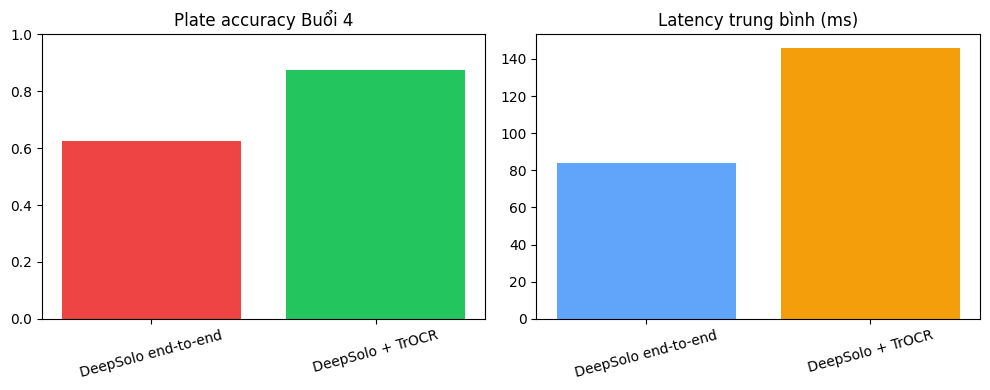

In [14]:
buoi4_results = {
    "DeepSolo end-to-end": {
        "cer": 0.0469,
        "wer": 0.3750,
        "plate_accuracy": 0.6250,
        "mean_latency_ms": 83.75,
    },
    "DeepSolo + TrOCR": {
        "cer": 0.0156,
        "wer": 0.1250,
        "plate_accuracy": 0.8750,
        "mean_latency_ms": 145.925,
    },
}

labels = list(buoi4_results)
plate_acc = [buoi4_results[name]["plate_accuracy"] for name in labels]
latency = [buoi4_results[name]["mean_latency_ms"] for name in labels]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(labels, plate_acc, color=["#ef4444", "#22c55e"])
axes[0].set_title("Plate accuracy Buổi 4")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=15)

axes[1].bar(labels, latency, color=["#60a5fa", "#f59e0b"])
axes[1].set_title("Latency trung bình (ms)")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

## 3. Schema prediction cho Buổi 5

Để đánh giá công bằng, mỗi dòng prediction nên có tối thiểu:

- `image_id`: mã ảnh hoặc tên file.
- `gt`: biển số đúng, đã được gán nhãn thủ công.
- `pred_raw`: chuỗi OCR thô trước hậu xử lý.
- `pred_norm`: chuỗi sau normalize/regex repair.
- `latency_ms`: thời gian xử lý nếu có.
- `error_type`: loại lỗi sau khi phân tích.

Script metric hiện tại chỉ cần `image_id`, `gt`, `pred`. Trong notebook này, `pred` sẽ lấy từ `pred_norm` để chấm kết quả sau hậu xử lý.

In [15]:
demo_rows = [
    {"image_id": "demo_001", "gt": "30A12345", "pred_raw": "30A12345", "latency_ms": 142.2},
    {"image_id": "demo_002", "gt": "51F67890", "pred_raw": "51F6789O", "latency_ms": 151.8},
    {"image_id": "demo_003", "gt": "29B11223", "pred_raw": "29B11223", "latency_ms": 139.4},
    {"image_id": "demo_004", "gt": "43C55667", "pred_raw": "43C55S67", "latency_ms": 160.5},
    {"image_id": "demo_005", "gt": "60A88888", "pred_raw": "60A88888", "latency_ms": 147.9},
    {"image_id": "demo_006", "gt": "15D23456", "pred_raw": "I5D23456", "latency_ms": 166.1},
    {"image_id": "demo_007", "gt": "59G13579", "pred_raw": "59G13579", "latency_ms": 144.0},
    {"image_id": "demo_008", "gt": "37H24680", "pred_raw": "37H2468O", "latency_ms": 149.7},
    {"image_id": "demo_009", "gt": "88K99999", "pred_raw": "88K99999", "latency_ms": 153.3},
    {"image_id": "demo_010", "gt": "30L54321", "pred_raw": "30L5432", "latency_ms": 158.6},
]


def classify_error(gt: str, pred_raw: str, pred_norm: str) -> str:
    gt_norm = normalize_plate_text(gt)
    raw_norm = normalize_plate_text(pred_raw)
    if pred_norm == gt_norm:
        if raw_norm == gt_norm:
            return "ok"
        return "postprocess_helped"
    if not pred_norm:
        return "detect_miss_or_empty_ocr"
    if len(pred_norm) != len(gt_norm):
        return "ocr_length_error"
    return "ocr_error"


if not PRED_CSV.exists():
    rows_to_write = []
    for row in demo_rows:
        pred_norm = repair_common_ocr_errors(row["pred_raw"])
        rows_to_write.append(
            {
                "image_id": row["image_id"],
                "gt": row["gt"],
                "pred_raw": row["pred_raw"],
                "pred_norm": pred_norm,
                "pred": pred_norm,
                "latency_ms": row["latency_ms"],
                "error_type": classify_error(row["gt"], row["pred_raw"], pred_norm),
            }
        )

    with PRED_CSV.open("w", newline="", encoding="utf-8") as fp:
        writer = csv.DictWriter(fp, fieldnames=list(rows_to_write[0].keys()))
        writer.writeheader()
        writer.writerows(rows_to_write)

    print("Đã tạo prediction demo:", PRED_CSV)
else:
    print("Đã có prediction CSV, giữ nguyên file hiện tại:", PRED_CSV)

Đã có prediction CSV, giữ nguyên file hiện tại: d:\ComputerVisionNew\outputs\buoi5\pred_vs_gt.csv


In [16]:
def load_prediction_rows(pred_csv: Path) -> list[dict[str, str]]:
    with pred_csv.open("r", encoding="utf-8") as fp:
        return list(csv.DictReader(fp))


rows = load_prediction_rows(PRED_CSV)
records = [
    EvalRecord(
        image_id=row.get("image_id", ""),
        gt=row.get("gt", ""),
        pred=row.get("pred_norm") or row.get("pred", ""),
        error_type=row.get("error_type", ""),
    )
    for row in rows
]

metrics = {
    "num_samples": len(records),
    "cer": cer(records),
    "wer": wer(records),
    "plate_accuracy": plate_accuracy(records),
    "mean_latency_ms": sum(float(row.get("latency_ms") or 0) for row in rows) / max(1, len(rows)),
}

METRICS_JSON.write_text(json.dumps(metrics, indent=2, ensure_ascii=False), encoding="utf-8")

print(json.dumps(metrics, indent=2, ensure_ascii=False))

{
  "num_samples": 10,
  "cer": 0.0625,
  "wer": 0.5,
  "plate_accuracy": 0.5,
  "mean_latency_ms": 151.35
}


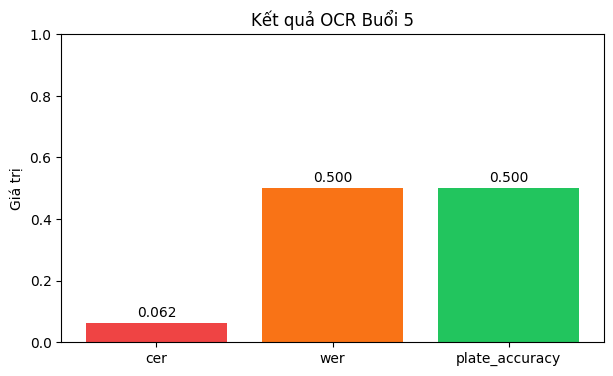

Số mẫu: 10
Latency trung bình: 151.35 ms


In [17]:
metric_names = ["cer", "wer", "plate_accuracy"]
metric_values = [metrics[name] for name in metric_names]
colors = ["#ef4444", "#f97316", "#22c55e"]

plt.figure(figsize=(7, 4))
plt.bar(metric_names, metric_values, color=colors)
plt.ylim(0, 1)
plt.title("Kết quả OCR Buổi 5")
plt.ylabel("Giá trị")
for idx, value in enumerate(metric_values):
    plt.text(idx, value + 0.02, f"{value:.3f}", ha="center")
plt.show()

print(f"Số mẫu: {metrics['num_samples']}")
print(f"Latency trung bình: {metrics['mean_latency_ms']:.2f} ms")

## 4. Đọc kết quả metric

Cách diễn giải nhanh:

- **CER càng thấp càng tốt**: cho biết trung bình sai bao nhiêu ký tự.
- **WER càng thấp càng tốt**: với biển số, thường khá nghiêm khắc vì sai một phần chuỗi có thể tính là sai cả token.
- **Plate accuracy càng cao càng tốt**: đây là metric quan trọng nhất khi mục tiêu là đọc đúng toàn bộ biển.
- **Latency** quyết định pipeline có đủ mượt cho demo video/webcam ở Buổi 6 hay không.

Với test set thật, nếu plate accuracy thấp nhưng CER không quá cao, thường lỗi nằm ở vài ký tự dễ nhầm. Khi đó nên ưu tiên hậu xử lý theo format biển số trước khi fine-tune model.

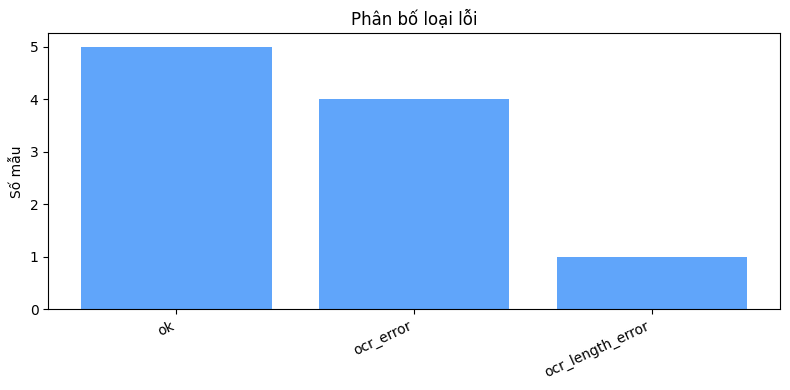

ok: 5
ocr_error: 4
ocr_length_error: 1


In [18]:
error_counts = Counter(record.error_type or "unknown" for record in records)

plt.figure(figsize=(8, 4))
plt.bar(error_counts.keys(), error_counts.values(), color="#60a5fa")
plt.title("Phân bố loại lỗi")
plt.ylabel("Số mẫu")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

for error_type, count in error_counts.most_common():
    print(f"{error_type}: {count}")

In [19]:
hard_cases = []
for row in rows:
    gt_norm = normalize_plate_text(row.get("gt", ""))
    pred_norm = normalize_plate_text(row.get("pred_norm") or row.get("pred", ""))
    if gt_norm != pred_norm:
        hard_cases.append(row)

with ERROR_CSV.open("w", newline="", encoding="utf-8") as fp:
    fieldnames = ["image_id", "gt", "pred_raw", "pred_norm", "latency_ms", "error_type"]
    writer = csv.DictWriter(fp, fieldnames=fieldnames)
    writer.writeheader()
    for row in hard_cases:
        writer.writerow({key: row.get(key, "") for key in fieldnames})

print("Số hard cases:", len(hard_cases))
print("Đã ghi:", ERROR_CSV)

for row in hard_cases[:10]:
    print(
        f"{row.get('image_id')}: "
        f"GT={row.get('gt')} | raw={row.get('pred_raw')} | "
        f"norm={row.get('pred_norm')} | type={row.get('error_type')}"
    )

Số hard cases: 5
Đã ghi: d:\ComputerVisionNew\reports\buoi5_error_records.csv
demo_002: GT=51F67890 | raw=51F6789O | norm=51F6789O | type=ocr_error
demo_004: GT=43C55667 | raw=43C55S67 | norm=43C55S67 | type=ocr_error
demo_006: GT=15D23456 | raw=I5D23456 | norm=I5D23456 | type=ocr_error
demo_008: GT=37H24680 | raw=37H2468O | norm=37H2468O | type=ocr_error
demo_010: GT=30L54321 | raw=30L5432 | norm=30L5432 | type=ocr_length_error


## 5. Thay dữ liệu demo bằng kết quả thật

Khi đã có model/checkpoint thật, chạy inference trước rồi quay lại notebook để xem kết quả.

Ví dụ với YOLOv8 + TrOCR baseline:

```bash
python scripts/run_infer.py --input-dir data/raw --output-json outputs/buoi5/predictions_trocr.json --detector-backend yolov8 --detector-model weights/yolov8_license_plate.pt --ocr-backend trocr --device cpu
```

Sau đó cần chuyển JSON prediction sang CSV có schema như phần trên, hoặc sửa cell đọc dữ liệu để đọc trực tiếp JSON.

Nếu DeepSolo chạy ở repo ngoài, chỉ cần export về cùng schema CSV:

```text
image_id,gt,pred_raw,pred_norm,pred,latency_ms,error_type
```

Rồi đặt file tại `outputs/buoi5/pred_vs_gt.csv` và chạy lại notebook từ đầu.

## 6. Checklist cuối Buổi 5

- Test set thật có ít nhất 200 ảnh và không trùng train/val.
- Pipeline chính DeepSolo + TrOCR chạy hết test set.
- Có ít nhất một baseline dự phòng để so sánh.
- Có file `outputs/buoi5/pred_vs_gt.csv` hoặc file tương đương.
- Có `reports/buoi5_metrics.json` với CER, WER, plate accuracy và latency.
- Có `reports/buoi5_error_records.csv` để đưa vào phần error analysis.
- Có 10-20 hard cases đã phân loại lỗi để dùng trong báo cáo và slide.

Kết luận cần ghi sau khi chạy dữ liệu thật: chọn cấu hình nào cho demo Buổi 6, vì sao chọn, và lỗi lớn nhất còn lại là gì.